## Profiling

In [16]:
import pandas as pd
import numpy as np
df = pd.read_csv('data/sample_changes.csv')

df.sort_values(by=['entity_id', 'property_id', 'value_id', 'timestamp'], inplace=True)

print('Number of changes', len(df))
print('Number of unique entities', len(df['entity_id'].unique()))
print('Number of unique properties', len(df['property_id'].unique()))
print('Number of properties per type', df.groupby(['property_type'])['property_id'].nunique())

df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

df.rename(columns={
    'first_revision_timestamp': 'entity_first_revision_timestamp', 
    'last_revision_timestamp': 'entity_last_revision_timestamp',
    'num_human_edits': 'entity_num_human_edits', 
    'num_bot_edits': 'entity_num_bot_edits', 
    'num_anonymous_edits': 'entity_num_anonymous_edits', 
    'num_reverted_edits': 'entity_num_reverted_edits',
    'num_value_changes': 'entity_num_value_changes',
    'num_revisions': 'entity_num_revisions',
    'num_value_change_creates': 'entity_num_value_change_creates',
    'num_value_change_deletes': 'entity_num_value_change_deletes',
    'num_value_change_updates': 'entity_num_value_change_updates',
    'num_unique_editors': 'entity_num_unique_editors'
}, inplace=True)

print(df.columns.to_list())


/tmp/ipykernel_497591/1122183562.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/sample_changes.csv')


Number of changes 411653
Number of unique entities 10583
Number of unique properties 623
Number of properties per type property_type
irregular    333
regular       57
static       233
Name: property_id, dtype: int64
['revision_id', 'property_id', 'property_label', 'value_id', 'old_value', 'new_value', 'old_datatype', 'new_datatype', 'change_target', 'action', 'target', 'old_hash', 'new_hash', 'timestamp', 'week', 'year_month', 'year', 'label', 'entity_id', 'is_reverted', 'reversion', 'reversion_timestamp', 'revision_id_reversion', 'entity_label', 'change_type', 'new_value_label', 'old_value_label', 'citation_needed', 'comment', 'user_id', 'user_type', 'entity_first_revision_timestamp', 'entity_last_revision_timestamp', 'entity_num_human_edits', 'entity_num_bot_edits', 'entity_num_anonymous_edits', 'entity_num_reverted_edits', 'num_reversions', 'entity_num_value_changes', 'entity_num_revisions', 'entity_num_value_change_creates', 'entity_num_value_change_deletes', 'entity_num_value_chan

## Functions (feature creation, selection, etc)

In [ ]:
NUMBER_OF_MONTHS_IN_THE_FUTURE = 6

from sklearn.preprocessing import MultiLabelBinarizer


def single_edit_features(df):
    """
    - user type
    - time of day of the edit (morning, afternoon, night)
    - time of the week (weekday, weekend)
    - keywords in comments 
    - change type 
    - action (create, delete, update)
    """

    numerical_features = []
    categorical_features = []
    binary_features = []

    # --------------------------------------------------
    #               CHANGE TYPE
    # --------------------------------------------------
    mlb = MultiLabelBinarizer()
    df['label'] = df['label'].str.replace('value_update', 'property_value_update')

    # label is only empty for UPDATES
    df['labels_list'] = np.where((df['action'] == 'CREATE') | (df['action'] == 'DELETE'), df['label'], np.where((df['action'] == 'UPDATE') & (df['change_type'] == ''), df['label'], df['change_type'] + ',' + df['label']))
    df['labels_list'] = df['labels_list'].fillna('')

    df['labels_list'] = df['labels_list'].str.split(',').apply(lambda x: [l.strip() for l in x])
    labels = mlb.fit_transform(df['labels_list'])

    df = df.reset_index(drop=True)
    df = pd.concat([df, pd.DataFrame(labels, columns=mlb.classes_)], axis=1)
    # NOTE: I have to do this because I also have rank changes and this can have no label if it's just a CREATE/DELETE of ranks, if it's soft deletion or soft insertion then they can have a change type
    df.drop(columns=[''], inplace=True) 

    change_types = mlb.classes_.tolist()

    change_types = [ct for ct in change_types if ct != '']

    binary_features.extend(change_types)
    
    # --------------------------------------------------
    #              SINGLE EDIT FEATURES
    # --------------------------------------------------
    df['hour'] = df['timestamp'].dt.hour
    time_of_day_conditions = [
        (df['hour'] <= 11) & (df['hour'] >= 6),
        (df['hour'] < 20) & (df['hour'] >= 12),
        (df['hour'] >= 20) | (df['hour'] < 6)
    ]
    time_of_day_choices = ['morning', 'afternoon', 'night']
    df['time_of_day'] = np.select(time_of_day_conditions, time_of_day_choices, default=None)
    df['time_of_week'] = np.where(df['timestamp'].dt.weekday > 4, 'weekend', 'weekday')

    GOOD_COMMENT_KEYWORDS = [' fix', 'correct', 'improve', 'repair', 'clean', 'error', 'wrong', 'mistake']
    df['comment_has_keyword'] = df['comment'].str.contains('|'.join(GOOD_COMMENT_KEYWORDS), case=False, na=False).astype(int)

    categorical_features.extend(['time_of_day', 'time_of_week', 'user_type', 'action', 'property_type']) # NOTE: user_type, action and property_type are already on the table, no need to calculate them
    binary_features.extend(['comment_has_keyword'])
    
    return df, numerical_features, categorical_features, binary_features

def edit_history_features(df):
    
    GROUP = ['entity_id', 'property_id', 'value_id']

    numerical_features = []
    categorical_features = []
    binary_features = []

    # --------------------------------------------------
    #               EDIT HISTORY FEATURES
    # --------------------------------------------------

    # Time to first edit of the value (in days)
    df['min_timestamp'] = df.groupby(GROUP)['timestamp'].transform('min')
    df['value_age_in_days_up_to_t'] = (df['timestamp'] - df['min_timestamp']).dt.total_seconds() / 86400  # in days

    numerical_features.extend(['value_age_in_days_up_to_t'])

    # NOTE: remove because they encode the target -> at least for reverted edits
    # df['num_reverted_edits_up_to_t'] = (
    #     df.groupby(['entity_id','property_id', 'value_id'])['is_reverted'] # is reverted is binary
    #     .cumsum()
    # ).fillna(0)

    # NOTE: I consider non-reverted those that are not reverted and that are also not reversions!!
    # NOTE: I shift because I want to count the number of non-reverted edits up to the current edit, 
    # so I don't want to count the current edit if it's non-reverted. If not I'm encoding the label
    df['is_clean'] = ((df['is_reverted'] == 0) & (df['reversion'] == 0)).astype(int)
    df['num_non_reverted_edits_before_t'] = (
        df.groupby(GROUP)['is_clean'].cumsum() - df['is_clean']
    ).fillna(0)

    df['total_changes_up_to_t'] = (
        df.groupby(['entity_id','property_id', 'value_id'])
        .cumcount() + 1 # starts at 0, so +1 to count the current edit as well
    )

    df['last_edit_time'] = df['timestamp'].shift(1) # timestamps are ordered
    df['time_to_previous_edit_days'] = (
        df.groupby(GROUP)['last_edit_time']
        .diff()
        .dt.total_seconds() / 86400
    )

    df['num_value_reoccurrences_at_t'] = (
        df.assign(is_same_value=1)
        .groupby(GROUP + ['new_value'])['is_same_value'] # grouping by new_value makes 1 group per value for the property-entity-value-id
        .cumsum() - 1  # -1 so the first appearance is 0, not 1
    )

    numerical_features.extend([
        # 'num_reverted_edits_up_to_t',
        'total_changes_up_to_t',
        'num_non_reverted_edits_before_t',
        'time_to_previous_edit_days',
        'num_value_reoccurrences_at_t'])

    # NOTE: This only considers previous edit of the value, but I should consider qualifier and reference changes

    df['type_of_previous_edit'] = df.groupby(['entity_id', 'property_id', 'value_id'])['action'].shift(1).fillna('None')
    categorical_features.extend(['type_of_previous_edit'])
    
    # --------------------------------------------------
    #           ENTITY CHARACTERISTICS FEATURES
    # --------------------------------------------------
    # NOTE: This are all calculated from the history of the entity, so they go in the edit history based features
    df['entity_age_days_at_t'] = (pd.to_datetime(df['timestamp'], utc=True) - pd.to_datetime(df['entity_first_revision_timestamp'], utc=True)).dt.days
    df['entity_pct_updates_to_total_edits'] = df['entity_num_value_change_updates'] / df['entity_num_value_changes']
    df['entity_pct_creates_to_total_edits'] = df['entity_num_value_change_creates'] / df['entity_num_value_changes']
    df['entity_pct_deletes_to_total_edits'] = df['entity_num_value_change_deletes'] / df['entity_num_value_changes']

    df['entity_pct_bot_edits'] = df['entity_num_bot_edits'] / df['entity_num_revisions']
    df['entity_pct_anonymous_edits'] = df['entity_num_anonymous_edits'] / df['entity_num_revisions']
    df['entity_pct_human_edits'] = df['entity_num_human_edits'] / df['entity_num_revisions']

    # entity is considered abandoned if it has not been edited for more than 1 year wrt to 2025-06-01 00:00:00
    df['entity_first_revision_timestamp'] = pd.to_datetime(df['entity_first_revision_timestamp'], utc=True)
    df['time_to_first_edit_of_entity_in_days_at_t'] = (df['timestamp'] - df['entity_first_revision_timestamp']).dt.days

    numerical_features.extend(['entity_age_days_at_t',
                            #    NOTE: I have to calculate all of this up to t if not I'm leaking infromation
                            # from the future
                            #    'entity_pct_updates_to_total_edits',
                            #    'entity_pct_creates_to_total_edits',
                            #    'entity_pct_deletes_to_total_edits',
                            #    'entity_pct_bot_edits',
                            #    'entity_pct_anonymous_edits',
                            #    'entity_pct_human_edits', 
                            #    'entity_num_unique_editors',
                               'time_to_first_edit_of_entity_in_days_at_t'
                               ])
    
    # binary_features.extend(['entity_abandoned'])

    # --------------------------------------------------
    #               USER FEATURES
    # --------------------------------------------------

    df_user_model = pd.read_csv('data/user_model.csv')

    df_with_user_info = df.merge(df_user_model[['user_id', 'first_edit']], on='user_id', how='left')

    df_with_user_info['user_age_days'] = np.where(df_with_user_info['user_type'] != 'anonymous', 
                                                  (pd.to_datetime(df_with_user_info['timestamp'], utc=True) - pd.to_datetime(df_with_user_info['first_edit'], utc=True)).dt.days, 
                                                  0)

    return df_with_user_info, numerical_features, categorical_features, binary_features

def create_target_column(df):
    GROUP = ['entity_id', 'property_id', 'value_id']
    NUMBER_OF_DAYS_IN_THE_FUTURE = NUMBER_OF_MONTHS_IN_THE_FUTURE * 30.44

    # 1) Values that get reverted
    #  NOTE: What happens with values that the reverted edit is done on the training and the reversion is 
    # later? If I have like a window for these cases I think I would be leaking information from the future to the training set
    df['reversion_timestamp'] = pd.to_datetime(df['reversion_timestamp'], utc=True)
    df['days_to_reversion'] = (df['reversion_timestamp'] - df['timestamp']).dt.days.astype('Int64').fillna(0)

    # days to reversion are within the time limit
    df['target_to_predict'] = np.where((df['is_reverted'] == 1) \
                                &
                                (df['days_to_reversion'] <= NUMBER_OF_DAYS_IN_THE_FUTURE), 1, 0)

    # TODO: Check if it can happen that a value is inserted and the id changes, I'm not sure if the id is created from the value - maybe check the hash?
    # 2) Values that get deleted AND never added again (I check this by value_id)
    #  {} new_value
    # new_value new_value 2 -> this one gets deleted
    # new_value_2 {} -> deleted
    # or
    # {} new_value -> this one gets deleted
    # new_value {}

    df_only_values = df[df['change_target'] == ''].copy()
    df_only_values['next_edit_action'] = df_only_values.groupby(GROUP)['action'].shift(-1).fillna('') # I want to check for deletes here
    df_only_values['next_edit_after_next'] = df_only_values.groupby(GROUP)['action'].shift(-2).fillna('') # to know it's the last one, I check this is NULL, so after the DELETE there's nothing more
    df_only_values['next_edit_timestamp'] = df_only_values.groupby(GROUP)['timestamp'].shift(-1) # I have to check that it gets deleted, does not appear again and this within 6 months

    df_only_values['is_deleted'] = np.where((df_only_values['next_edit_action'] == 'DELETE') & (df_only_values['next_edit_after_next'] == '') & (df_only_values['next_edit_timestamp'].notna()) & (df_only_values['next_edit_timestamp'] <= df_only_values['timestamp'] + pd.Timedelta(days=NUMBER_OF_DAYS_IN_THE_FUTURE)), 1, 0)

    df = pd.merge(df, df_only_values[['revision_id','entity_id', 'property_id', 'value_id', 'is_deleted']], on=['revision_id','entity_id', 'property_id', 'value_id'], how='left')

    df['target_to_predict'] = np.where((df['target_to_predict'] == 1) | (df['is_deleted'] == 1), 1, 0)

    return df

def select_features(numerical_features, categorical_features, binary_features, type_='changes_anonymous'):
    if type_ == 'changes_anonymous':
        numerical_features = [f for f in numerical_features if 'user' not in f]
        categorical_features = [f for f in categorical_features if 'user' not in f]
        binary_features = [f for f in binary_features if 'user' not in f]
    
    return numerical_features, categorical_features, binary_features

def separate_anonymous_changes(df):
    df_changes_no_anonymous = df[df['user_type'] != 'anonymous'].copy()
    df_changes_anonymous = df[df['user_type'] == 'anonymous'].copy()

    return df_changes_anonymous, df_changes_no_anonymous

## Feature creation

In [18]:
df['change_target'] = df['change_target'].fillna('')
df.sort_values(by=['entity_id', 'property_id', 'value_id', 'timestamp'], inplace=True)

df, numerical_features_single, categorical_features_single, binary_features_single = single_edit_features(df)
df, numerical_features_history, categorical_features_history, binary_features_history = edit_history_features(df)

numerical_features = numerical_features_single + numerical_features_history
categorical_features = categorical_features_single + categorical_features_history
binary_features = binary_features_single + binary_features_history

print('Features created:')
print('Numerical features:', numerical_features)
print('Categorical features:', categorical_features)
print('Binary features:', binary_features)


Features created:
Numerical features: ['value_age_in_days_up_to_t', 'total_changes_up_to_t', 'num_non_reverted_edits_before_t', 'time_to_previous_edit_days', 'num_value_reoccurrences_at_t', 'entity_age_days_at_t', 'time_to_first_edit_of_entity_in_days_at_t']
Categorical features: ['time_of_day', 'time_of_week', 'user_type', 'action', 'property_type', 'type_of_previous_edit']
Binary features: ['statement_deletion', 'statement_insertion', 'comment_has_keyword']


## Training

In [ ]:

### ------------------------------------------------------------------------------
#               MODEL TRAINING AND EVALUATION
### ------------------------------------------------------------------------------

import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, roc_auc_score, classification_report, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import json
import pickle

df_changes_anonymous, df_changes_no_anonymous = separate_anonymous_changes(df)

types = ['changes_anonymous', 'changes_no_anonymous']

classifiers = {}

TRAINING_CUT_OFF = pd.Timestamp('2022-05-01', tz='UTC')

for type_, df_type in zip(types, [df_changes_anonymous, df_changes_no_anonymous]):

    print('[TYPE] - ', type_)

    numerical_features, categorical_features, binary_features = select_features(numerical_features, categorical_features, binary_features, type_=type_)
    feature_cols = numerical_features + categorical_features + binary_features
    print('[FEATURES]')
    for feature in feature_cols:
        print(feature)

    categorical_pipeline = Pipeline([
        ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    binary_pipeline = Pipeline([
        ("passthrough", "passthrough")
    ])

    numerical_pipeline = Pipeline([
        ("power_transform", PowerTransformer(method='yeo-johnson')), # works for positive and negative skew values
        ("scaler", StandardScaler())
    ])

    preprocessing_pipeline = ColumnTransformer([
        ("categorical_preprocessor", categorical_pipeline, categorical_features),
        ("binary", binary_pipeline, binary_features),
        ("numerical_preprocessor", numerical_pipeline, numerical_features)
    ])

    # NOTE: I create the target column after the split because I don't want to leak information from the future into the training set
    df_train = df_type[df_type['timestamp'] < TRAINING_CUT_OFF].copy()
    df_test = df_type[df_type['timestamp'] >= TRAINING_CUT_OFF].copy()

    df_train = create_target_column(df_train)
    df_test = create_target_column(df_test)

    print('[TRAINING DATASET] - Distribution of target_to_predict label')
    len_df_test = len(df_train)
    len_positive_class = df_train['target_to_predict'].sum()
    print('Ratio positive class', f'{(len_positive_class / len_df_test if len_df_test > 0 else 0):.2f}')
    print('Ratio negative class', f'{((len_df_test - len_positive_class) / len_df_test if len_df_test > 0 else 0):.2f}')
    print()

    print('[TEST DATASET] - Distribution of target_to_predict label')
    len_df_test = len(df_test)
    len_df_test_positive_class = df_test['target_to_predict'].sum()
    print('Ratio positive class', f'{(len_df_test_positive_class / len_df_test if len_df_test > 0 else 0):.2f}')
    print('Ratio negative class', f'{((len_df_test - len_df_test_positive_class) / len_df_test if len_df_test > 0 else 0):.2f}')
    print()

    os.makedirs('training', exist_ok=True)

    df_train.to_csv(f'training/train_dataset_{type_}.csv', index=False)
    df_test.to_csv(f'training/test_dataset_{type_}.csv', index=False)

    # NOTE: Remove rank changes, I only use them for the target_to_predict label
    df_train = df_train[(df_train['change_target'] == '') & (df_train['action'] != 'DELETE')].copy()
    df_test = df_test[(df_test['change_target'] == '') & (df_test['action'] != 'DELETE')].copy()

    X_train = df_train[feature_cols].fillna(0)
    y_train = df_train['target_to_predict']
    X_test = df_test[feature_cols].fillna(0)
    y_test = df_test['target_to_predict']

    # Train classifier
    clf_rf = RandomForestClassifier(
        class_weight='balanced',  # NOTE: the dataset is quite imbalanced
        random_state=42)

    params = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }
    gs = GridSearchCV(
            clf_rf,
            param_grid=params,
            cv=3,
            scoring='f1',
            verbose=2,
            refit=True
    )

    pipeline = Pipeline([
        ("preprocessing", preprocessing_pipeline),
        ("classifier", gs)
    ])
    pipeline.fit(X_train, y_train)

    # Evaluate
    # y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    # precision = precision_score(y_test, (y_pred_proba > 0.5).astype(int))
    # recall = recall_score(y_test, (y_pred_proba > 0.5).astype(int))

    y_pred = pipeline.predict(X_test)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)

    df_test['prediction'] = y_pred
    df_test.to_csv(f'training/test_predictions_{type_}.csv', index=False)

    with open(f'training/grid_search_results_{type_}.json', 'w') as f:
        json.dump({
            "best_parameters": gs.best_params_,
            "best_score": gs.best_score_,
            "precision": precision,
            "recall": recall,
            "roc_auc": roc_auc
        }, f)
    
    with open(f'training/random_forest_model_{type_}.pkl', 'wb') as f:
        pickle.dump(pipeline, f)

    print(f"Random Forest:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print()

    print(f"Classification Report:\n{classification_rep}")

    classifiers[type_] = {
        "pipeline": pipeline,
        'precision': precision,
        'recall': recall,
        'feature_cols': feature_cols
    }

# took 13 minutes to do both grid searches


[TYPE] -  changes_anonymous
[FEATURES]
value_age_in_days_up_to_t
total_changes_up_to_t
num_non_reverted_edits_before_t
time_to_previous_edit_days
num_value_reoccurrences_at_t
entity_age_days_at_t
time_to_first_edit_of_entity_in_days_at_t
time_of_day
time_of_week
action
property_type
type_of_previous_edit
statement_deletion
statement_insertion
comment_has_keyword
[TRAINING DATASET] - Distribution of target_to_predict label
Ratio positive class 0.55
Ratio negative class 0.45

[TEST DATASET] - Distribution of target_to_predict label
Ratio positive class 0.57
Ratio negative class 0.43

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 

### Prediction validation

In [32]:
import pandas as pd

type_ = 'changes_no_anonymous'  # or 'changes_no_anonymous'

df_test_predictions = pd.read_csv(f'training/test_predictions_{type_}.csv')

df_test_predictions['change_target'] = df_test_predictions['change_target'].fillna('')

df_original = pd.read_csv(f'training/test_dataset_{type_}.csv')
df_original['timestamp'] = pd.to_datetime(df_original['timestamp'], utc=True)
df_original.sort_values(by=['entity_id', 'property_id', 'value_id', 'timestamp'], inplace=True)
df_original['change_target'] = df_original['change_target'].fillna('')

df = pd.merge(df_original, df_test_predictions[['revision_id', 'entity_id', 'property_id', 'value_id', 'change_target','target_to_predict', 'prediction']], on=['revision_id', 'entity_id', 'property_id', 'value_id', 'change_target'], how='left')
df['prediction'] = df['prediction'].fillna(0).astype(int)

print(df.columns.to_list())
# rejected values
# pick 1
rejected = df[(df['prediction'] == 1) & (df['action'] != 'DELETE') & (df['change_target'] == '')].copy()
display(rejected[['entity_id', 'entity_label', 'property_id', 'property_label', 'value_id', 'old_value', 'new_value']].head(50))

display(df[(df['entity_id']== 66) & \
                 (df['property_id']== 571) & \
                 (df['value_id']== 'Q66$a965ea32-4d04-176f-e14e-b0f0a4988d0d') &\
                    (df['change_target'] == '')
                 ][['entity_id', 'entity_label', 'property_id', 'property_label', 'value_id', 'old_value', 'old_value_label', 'new_value','new_value_label', 'is_reverted', 'target_to_predict_x', 'prediction', 'user_type', 'timestamp', 'num_value_reoccurrences_at_t']])

# display(df[(df['entity_id']== 177) & \
#                  (df['property_id']== 495) & \
#                  (df['value_id']== 'Q177$47222051-4c78-6d4c-2fc3-df888183f01f') \
#                  ][['entity_id', 'entity_label', 'property_id', 'value_id', 'old_value', 'old_value_label', 'new_value', 'new_value_label', 'is_reverted', 'target_to_predict', 'prediction', 'num_value_reoccurrences_at_t']])

['revision_id', 'property_id', 'property_label', 'value_id', 'old_value', 'new_value', 'old_datatype', 'new_datatype', 'change_target', 'action', 'target', 'old_hash', 'new_hash', 'timestamp', 'week', 'year_month', 'year', 'label', 'entity_id', 'is_reverted', 'reversion', 'reversion_timestamp', 'revision_id_reversion', 'entity_label', 'change_type', 'new_value_label', 'old_value_label', 'citation_needed', 'comment', 'user_id', 'user_type', 'entity_first_revision_timestamp', 'entity_last_revision_timestamp', 'entity_num_human_edits', 'entity_num_bot_edits', 'entity_num_anonymous_edits', 'entity_num_reverted_edits', 'num_reversions', 'entity_num_value_changes', 'entity_num_revisions', 'entity_num_value_change_creates', 'entity_num_value_change_deletes', 'entity_num_value_change_updates', 'entity_num_unique_editors', 'property_type', 'labels_list', 'statement_deletion', 'statement_insertion', 'hour', 'time_of_day', 'time_of_week', 'comment_has_keyword', 'min_timestamp', 'value_age_in_days

,entity_id,entity_label,property_id,property_label,value_id,old_value,new_value
21,5,human,31,instance of,Q5$2b88f743-4ae7-7657-16a3-f215398c0f64,{},"""Q16521"""
25,5,human,31,instance of,Q5$65CCAE26-B0A5-4D56-BF2A-4497CFB89862,{},"""Q1041"""
39,5,human,31,instance of,Q5$8345C35C-33CB-42CA-8C28-7A39FF6C7D1C,{},"""Q95074"""
43,5,human,31,instance of,Q5$DFC035F5-C62F-4FA0-B82F-CF0316A25B31,{},"""Q21286738"""
47,5,human,31,instance of,Q5$a5ed37f5-422a-d36f-04ef-6278e6363aef,{},"""Q164509"""
56,5,human,31,instance of,Q5$dda90483-4098-3b9e-1079-64a0d572c729,{},"""Q16521"""
72,5,human,138,named after,Q5$f87a9183-4dfd-c2c0-6874-7bf1366b2123,{},"""Q70899"""
76,5,human,225,taxon name,Q5$12f4e2de-46b8-c95e-9350-33559438f3e3,{},"""Homo sapiens"""
79,5,human,225,taxon name,Q5$9b62c9b1-4dfd-9ed2-9ce6-1ffec82addce,{},"""Homo sapiens"""
84,5,human,569,date of birth,Q5$CC5D150A-9DAA-4720-AF40-B094D3461CB4,{},"""+1969-00-00T00:00:00Z"""


,entity_id,entity_label,property_id,property_label,value_id,old_value,old_value_label,new_value,new_value_label,is_reverted,target_to_predict_x,prediction,user_type,timestamp,num_value_reoccurrences_at_t
5762,66,Boeing,571,inception,Q66$a965ea32-4d04-176f-e14e-b0f0a4988d0d,{},NaN,"""+1934-00-00T00:00:00Z""",NaN,0,0,1,human,2023-01-08 02:16:15+00:00,0


### Feature importance

Number of features after preprocessing: 31
Number of importances: 31


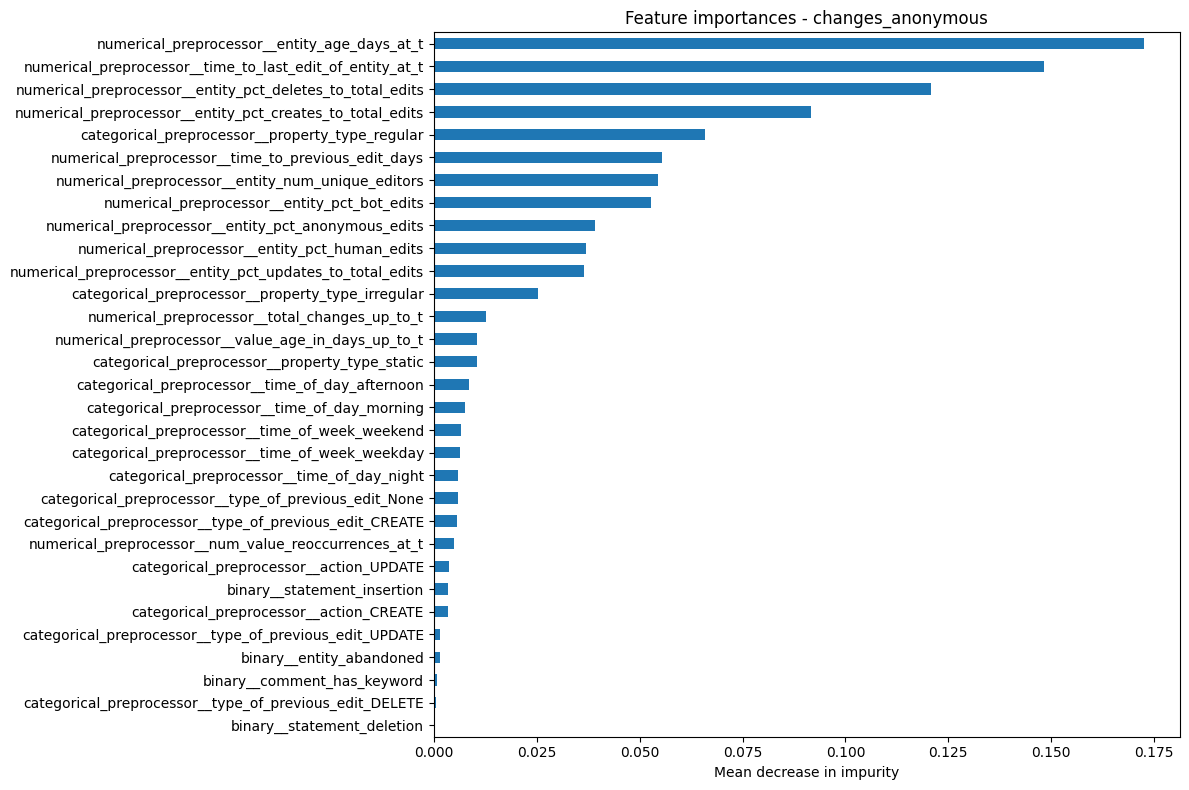

Number of features after preprocessing: 31
Number of importances: 31


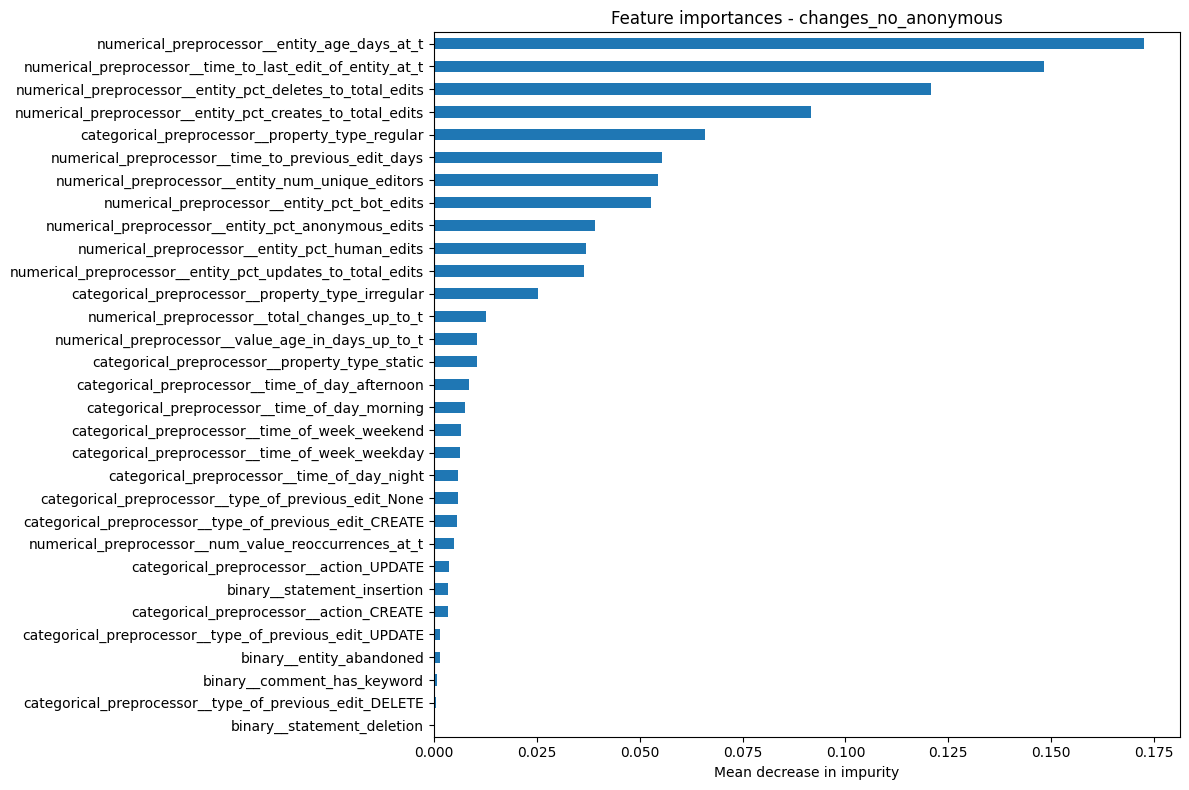

AttributeError: 'GridSearchCV' object has no attribute 'feature_importances_'

In [ ]:

import matplotlib.pyplot as plt

types = ['changes_anonymous']
for type_ in types:
    preprocessor = pipeline.steps[0][1]  # column transformrs
    clf = pipeline.steps[1][1].best_estimator_  # classifier
    
    importances = clf.feature_importances_
    
    # Get feature names AFTER preprocessing
    feature_names = preprocessor.get_feature_names_out()

    feature_cols = [f.replace('numerical_preprocessor__', '').replace('categorical_preprocessor__', '').replace('binary_preprocessor__', '') for f in feature_names]
    
    print(f"Number of features after preprocessing: {len(feature_names)}")
    print(f"Number of importances: {len(importances)}")
    
    forest_importances = pd.Series(importances, index=feature_names)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    forest_importances.sort_values().plot.barh(ax=ax)
    ax.set_title(f"Feature importances - {type_}")
    ax.set_xlabel("Mean decrease in impurity")
    fig.tight_layout()
    plt.show()

# for feat, imp in zip(classifiers[type_]['feature_cols'], classifiers[type_]['pipeline'].steps[1][1].feature_importances_):
    
#     print(f"{feat}: {imp:.4f}")

## Anonymous Baseline

In [ ]:
# Run baselines 
from sklearn.metrics import precision_score, recall_score, f1_score

def baseline_anonymous(df):
    # Predicts that every rejection done by anonymous editor is unreliable

    print('Number of anonymous edits', len(df[df['user_type'] == 'anonymous']))
    print('Number of anonymous edits that are rejected', len(df[(df['user_type'] == 'anonymous') & (df['target_to_predict'] == 1)]))
    print('Number of rejected edits', len(df[df['target_to_predict'] == 1]))
    print('Number of non anonymous edits that are rejected', len(df[(df['user_type'] != 'anonymous') & (df['target_to_predict'] == 1)]))
    df['prediction_anonymous'] = np.where((df['user_type'] == 'anonymous') & (df['target_to_predict'] == 1), 1, 0)

    return df

df_baseline_anonymous = baseline_anonymous(df_test)

precision_baseline_anonymous = precision_score(df_baseline_anonymous['target_to_predict'], df_baseline_anonymous['prediction_anonymous'])
recall_baseline_anonymous = recall_score(df_baseline_anonymous['target_to_predict'], df_baseline_anonymous['prediction_anonymous'])
f1_baseline_anonymous = f1_score(df_baseline_anonymous['target_to_predict'], df_baseline_anonymous['prediction_anonymous'])

print(f"Baseline Anonymous:")
print(f"Precision: {precision_baseline_anonymous:.4f}")
print(f"Recall: {recall_baseline_anonymous:.4f}")
print(f"F1-Score: {f1_baseline_anonymous:.4f}")


Number of anonymous edits 876
Number of anonymous edits that are rejected 417
Number of rejected edits 1793
Number of non anonymous edits that are rejected 1376
Baseline Anonymous:
Precision: 1.0000
Recall: 0.2326
F1-Score: 0.3774


**Anonymous baseline**

If precision = 1 then FP = 0 (I don't classify as rejected values that aren't rejected in X months)

Recall is low then FN > 0 (I classify as not rejected values that are rejected)

## Static Baseline

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('data/sample_changes.csv')

df.sort_values(by=['entity_id', 'property_id', 'value_id', 'timestamp'], inplace=True)

print('Number of changes', len(df))
print('Number of unique entities', len(df['entity_id'].unique()))
print('Number of unique properties', len(df['property_id'].unique()))
print('Number of properties per type', df.groupby(['property_type'])['property_id'].nunique())

df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

df.rename(columns={
    'first_revision_timestamp': 'entity_first_revision_timestamp', 
    'last_revision_timestamp': 'entity_last_revision_timestamp',
    'num_human_edits': 'entity_num_human_edits', 
    'num_bot_edits': 'entity_num_bot_edits', 
    'num_anonymous_edits': 'entity_num_anonymous_edits', 
    'num_reverted_edits': 'entity_num_reverted_edits',
    'num_value_changes': 'entity_num_value_changes',
    'num_revisions': 'entity_num_revisions',
    'num_value_change_creates': 'entity_num_value_change_creates',
    'num_value_change_deletes': 'entity_num_value_change_deletes',
    'num_value_change_updates': 'entity_num_value_change_updates',
    'num_unique_editors': 'entity_num_unique_editors'
}, inplace=True)

print(df.columns.to_list())


#  check distinct values per property -> this can help see properties that get new values as updates vs those that get new values as creates

df_ent_prop = df.groupby(['entity_id','property_id'])['value_id'].nunique().reset_index().rename(columns={'value_id': 'num_distinct_values'})


df_ent_prop= df_ent_prop.groupby('property_id').agg({'num_distinct_values': 'mean'}).reset_index().rename(columns={'num_distinct_values': 'avg_num_distinct_values_per_property'})

df['change_target'] = df['change_target'].fillna('')
df.sort_values(by=['entity_id', 'property_id', 'value_id', 'timestamp'], inplace=True)


df, numerical_features, categorical_features, binary_features = single_edit_features(df)